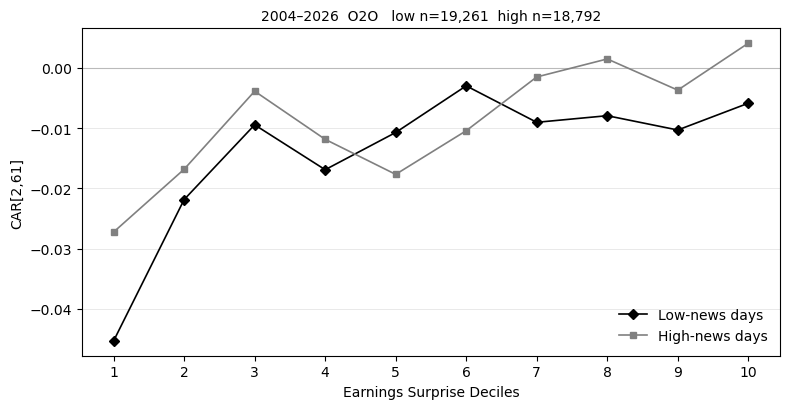

SUE10−SUE1 价差: low +3.94% | high +3.13% | 差(10−1) -0.81%
          low  high
sue_dec            
1.0     -4.53 -2.73
2.0     -2.19 -1.68
3.0     -0.95 -0.39
4.0     -1.69 -1.19
5.0     -1.07 -1.77
6.0     -0.30 -1.05
7.0     -0.91 -0.15
8.0     -0.80  0.15
9.0     -1.03 -0.37
10.0    -0.59  0.41


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- 参数 ----
YEARS = (2004, 2026)          # 原文样本期 1995-2004；改 (2004, 2026) 看后半段
CONV = "o2o"                  # "c2c" / "o2o"
WIN = "drift"                 # "drift" = Figure 2 CAR[2,61]；"ann" = Figure 1 CAR[0,1]
LOW, HIGH = [1], [10]         # 原文：NRANK 底部十分位 vs 顶部十分位

col = f"car_{WIN}_{CONV}"
p = pd.read_parquet("build/pead_panel.parquet",
    columns=["anndats", "sue_dec", "nrank", col,
             "is_latest_pends_on_day", "flag_lag_bad", "flag_pre_calendar"])
d = p[p.is_latest_pends_on_day & ~p.flag_lag_bad & ~p.flag_pre_calendar]
d = d.dropna(subset=["sue_dec", "nrank", col])
d = d[d.anndats.dt.year.between(*YEARS)]

L = d[d.nrank.isin(LOW)].groupby("sue_dec")[col].mean()
H = d[d.nrank.isin(HIGH)].groupby("sue_dec")[col].mean()
nL, nH = int(d.nrank.isin(LOW).sum()), int(d.nrank.isin(HIGH).sum())

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(L.index, L.values, "-D", color="black", ms=5, lw=1.2, label="Low-news days")
ax.plot(H.index, H.values, "-s", color="gray", ms=5, lw=1.2, label="High-news days")
ax.axhline(0, color="0.75", lw=0.8, zorder=0)

ax.set_xticks(range(1, 11))
ax.set_xlabel("Earnings Surprise Deciles")
ax.set_ylabel(f"CAR[{'2,61' if WIN == 'drift' else '0,1'}]")
ax.set_title(f"{YEARS[0]}–{YEARS[1]}  {CONV.upper()}   low n={nL:,}  high n={nH:,}", fontsize=10)
ax.legend(frameon=False, loc="lower right")

ax.grid(axis="y", lw=0.4, alpha=0.5)
fig.tight_layout()
plt.show()

gl, gh = (L.loc[10] - L.loc[1]) * 100, (H.loc[10] - H.loc[1]) * 100
print(f"SUE10−SUE1 价差: low {gl:+.2f}% | high {gh:+.2f}% | 差(10−1) {gh - gl:+.2f}%")
print(pd.DataFrame({"low": L, "high": H}).mul(100).round(2).to_string())


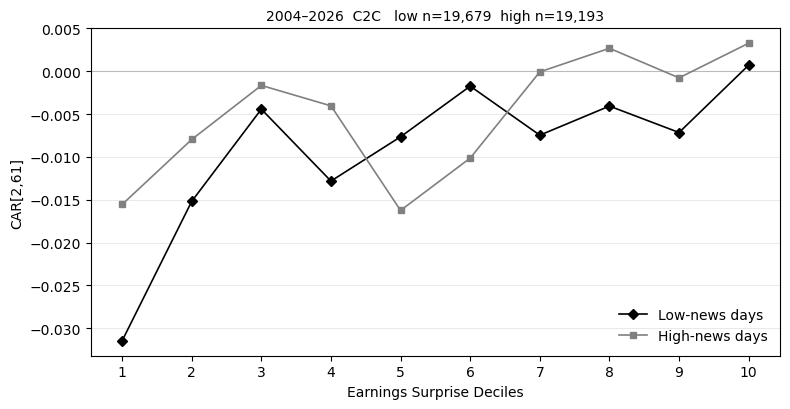

SUE10−SUE1 价差: low +3.22% | high +1.88% | 差(10−1) -1.34%
          low  high
sue_dec            
1.0     -3.15 -1.56
2.0     -1.52 -0.80
3.0     -0.44 -0.17
4.0     -1.28 -0.40
5.0     -0.76 -1.62
6.0     -0.17 -1.01
7.0     -0.75 -0.01
8.0     -0.41  0.27
9.0     -0.71 -0.08
10.0     0.07  0.33


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- 参数 ----
YEARS = (2004, 2026)          # 原文样本期 1995-2004；改 (2004, 2026) 看后半段
CONV = "c2c"                  # "c2c" / "o2o"
WIN = "drift"                 # "drift" = Figure 2 CAR[2,61]；"ann" = Figure 1 CAR[0,1]
LOW, HIGH = [1], [10]         # 原文：NRANK 底部十分位 vs 顶部十分位

col = f"car_{WIN}_{CONV}"
p = pd.read_parquet("build/pead_panel.parquet",
    columns=["anndats", "sue_dec", "nrank", col,
             "is_latest_pends_on_day", "flag_lag_bad", "flag_pre_calendar"])
d = p[p.is_latest_pends_on_day & ~p.flag_lag_bad & ~p.flag_pre_calendar]
d = d.dropna(subset=["sue_dec", "nrank", col])
d = d[d.anndats.dt.year.between(*YEARS)]

L = d[d.nrank.isin(LOW)].groupby("sue_dec")[col].mean()
H = d[d.nrank.isin(HIGH)].groupby("sue_dec")[col].mean()
nL, nH = int(d.nrank.isin(LOW).sum()), int(d.nrank.isin(HIGH).sum())

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(L.index, L.values, "-D", color="black", ms=5, lw=1.2, label="Low-news days")
ax.plot(H.index, H.values, "-s", color="gray", ms=5, lw=1.2, label="High-news days")
ax.axhline(0, color="0.75", lw=0.8, zorder=0)

ax.set_xticks(range(1, 11))
ax.set_xlabel("Earnings Surprise Deciles")
ax.set_ylabel(f"CAR[{'2,61' if WIN == 'drift' else '0,1'}]")
ax.set_title(f"{YEARS[0]}–{YEARS[1]}  {CONV.upper()}   low n={nL:,}  high n={nH:,}", fontsize=10)
ax.legend(frameon=False, loc="lower right")

ax.grid(axis="y", lw=0.4, alpha=0.5)
fig.tight_layout()
plt.show()

gl, gh = (L.loc[10] - L.loc[1]) * 100, (H.loc[10] - H.loc[1]) * 100
print(f"SUE10−SUE1 价差: low {gl:+.2f}% | high {gh:+.2f}% | 差(10−1) {gh - gl:+.2f}%")
print(pd.DataFrame({"low": L, "high": H}).mul(100).round(2).to_string())
